# Experiment 2 — Student Engagement Analysis

7+ thesis-quality figures comparing R0 (generic RAG) vs R1 (FSLSM-personalized RAG).  
**Cell 1 (Config)** — set `EXPERIMENT = 'new'` (post-fix, current) or `'old'` (run2_backup, pre-fix) to toggle between runs. Re-run the notebook after switching.


In [2]:
from pathlib import Path

# ── Experiment selector ────────────────────────────────────────────────
# Switch between the two completed full runs of Experiment 2.
#   'new' → current run with RR-improvement fixes A/B/C applied (Apr 26–28)
#   'old' → run2_backup, prior to fixes (showed RR inversion R1 < R0)
# Switch to compare results across runs without rebuilding the notebook.
EXPERIMENT = 'old'   # ← change to 'old' to view run2_backup results

EXPERIMENT_PATHS = {
    'new': Path('results'),                 # post-fix, RR inversion resolved
    'old': Path('results/run2_backup'),     # pre-fix baseline
}

if EXPERIMENT not in EXPERIMENT_PATHS:
    raise ValueError(f"EXPERIMENT must be one of {list(EXPERIMENT_PATHS)}, got {EXPERIMENT!r}")

# ── Paths (derived) ────────────────────────────────────────────────────
RESULTS_DIR = EXPERIMENT_PATHS[EXPERIMENT]
CSV_PATH    = RESULTS_DIR / 'exp2_session_metrics.csv'
JSON_PATH   = RESULTS_DIR / 'exp2_results_summary.json'
FIG_DIR     = RESULTS_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Loading EXPERIMENT={EXPERIMENT!r} from {RESULTS_DIR}")

# ── Palette ────────────────────────────────────────────────────────────
C_R0   = '#5B8DB8'   # blue  — control condition
C_R1   = '#E07B54'   # orange — personalized condition
C_NEG  = '#BBBBBB'   # grey for negative lift bars
ALPHA  = 0.85
FIG_DPI = 150

# ── FSLSM dimension config ─────────────────────────────────────────────
DIM_NAMES  = ['act_ref', 'sen_int', 'vis_ver', 'seq_glo']
DIM_TITLES = ['Active / Reflective', 'Sensing / Intuitive',
               'Visual / Verbal', 'Sequential / Global']
DIM_LABELS = {
    'act_ref': { 1: 'Active',      -1: 'Reflective'},
    'sen_int': { 1: 'Sensing',     -1: 'Intuitive'},
    'vis_ver': { 1: 'Visual',      -1: 'Verbal'},
    'seq_glo': { 1: 'Sequential',  -1: 'Global'},
}

# ── Metric mapping: CSV col → display label → summary JSON key ─────────
METRIC_COLS   = ['scs', 'rr', 'cr5', 'engagement', 'er']
METRIC_LABELS = ['SCS', 'RR', 'CR@5', 'Engagement', 'ER']
METRIC_JSON   = ['SCS', 'RR', 'CR@5', 'Eng', 'ER']   # keys in exp2_results_summary.json


Loading EXPERIMENT='old' from results/run2_backup


## Imports & Data Load

In [3]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.0)

# Load session-level metrics
df = pd.read_csv(CSV_PATH)
for dim in DIM_NAMES:
    df[dim] = df[dim].astype(int)

# Load summary JSON
with open(JSON_PATH) as f:
    summary = json.load(f)

df_r0 = df[df['mode'] == 'R0'].copy()
df_r1 = df[df['mode'] == 'R1'].copy()

print(f'R0 sessions : {len(df_r0)}')
print(f'R1 sessions : {len(df_r1)}')
print(f'Profiles    : {df["profile_label"].nunique()}')
print(f'Questions   : {df["question_id"].nunique()}')
df.head(3)


R0 sessions : 5760
R1 sessions : 5760
Profiles    : 16
Questions   : 72


,agent_id,question_id,mode,profile_label,act_ref,sen_int,vis_ver,seq_glo,scs,rr,cr5,cr10,er,engagement,latency_ms,token_count,tutor_cost
0,P15_RefIntVerSeq_I01_beg,MH_032,R0,Reflective-Intuitive-Verbal-Sequential,1,1,1,-1,0.2852,5,0.0,0.3333,0.0,4,20485,3571,0.001822
1,P16_RefIntVerGlo_I03_adv,MH_024,R0,Reflective-Intuitive-Verbal-Global,1,1,1,1,0.2240,5,0.0,0.5000,0.0,4,10993,3779,0.002712
2,P07_ActIntVerSeq_I02_int,MH_058,R0,Active-Intuitive-Verbal-Sequential,-1,1,1,-1,0.2700,5,0.5,1.0000,1.0,3,9627,2968,0.002326


In [4]:
# ── Merge question metadata (type & strategy) into df ─────────────────
Q_META_PATH = Path('../../data/exp2/sampled_questions.json')
with open(Q_META_PATH) as f:
    q_raw = json.load(f)

q_meta = {q['question_id']: q for q in q_raw}
df['question_type'] = df['question_id'].map(lambda x: q_meta.get(x, {}).get('question_type'))
df['strategy']      = df['question_id'].map(lambda x: q_meta.get(x, {}).get('strategy'))

print('Question type distribution:')
print(df[df['mode']=='R0']['question_type'].value_counts().to_string())
print('\nStrategy distribution:')
print(df[df['mode']=='R0']['strategy'].value_counts().to_string())

Question type distribution:
question_type
explain_relationship    2720
synthesize_workflow     2080
trace_evolution          480
compare                  480

Strategy distribution:
strategy
intra_cluster         2880
prerequisite_chain    1520
cross_topic           1360


## Fig 1 — Engagement by FSLSM Dimension (grouped bar)
Primary result chart for the student agent. Shows mean engagement per learning-style pole, R0 vs R1 side-by-side.

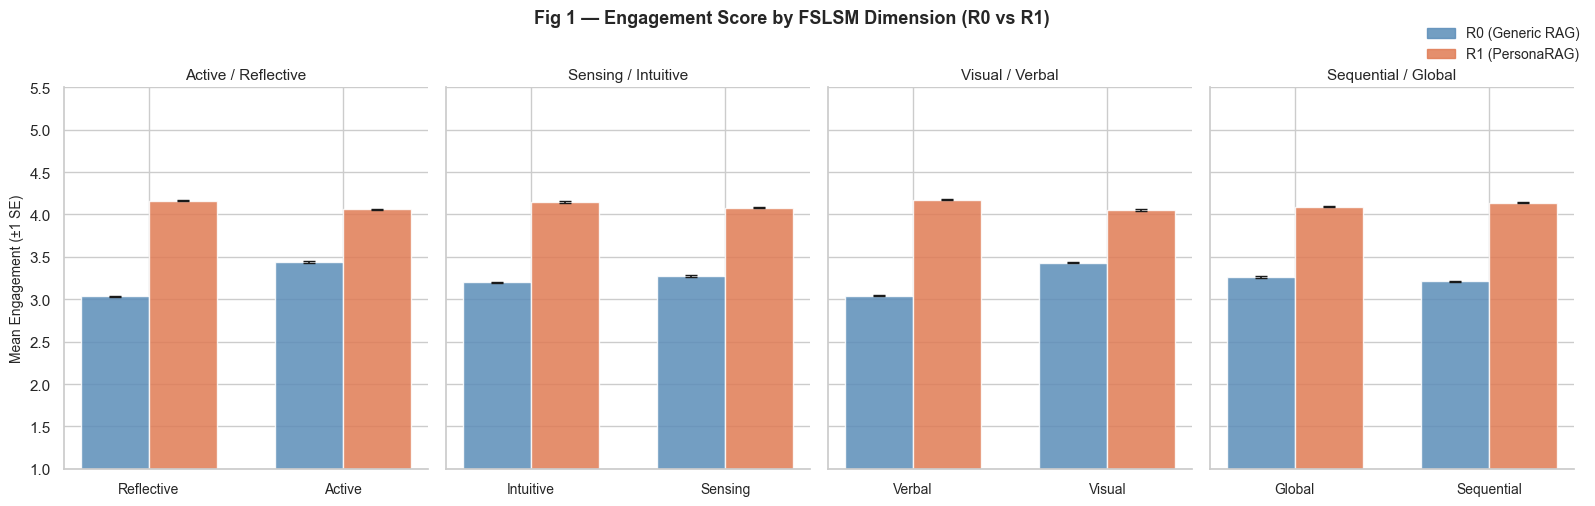

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
fig.suptitle('Fig 1 — Engagement Score by FSLSM Dimension (R0 vs R1)',
             fontsize=13, fontweight='bold', y=1.01)

bar_w = 0.35
patch_r0 = mpatches.Patch(color=C_R0, alpha=ALPHA, label='R0 (Generic RAG)')
patch_r1 = mpatches.Patch(color=C_R1, alpha=ALPHA, label='R1 (PersonaRAG)')

for ax, dim, title in zip(axes, DIM_NAMES, DIM_TITLES):
    poles = sorted(df[dim].unique())       # [-1, 1]
    labels = [DIM_LABELS[dim][p] for p in poles]
    r0_m, r0_se, r1_m, r1_se = [], [], [], []

    for pole in poles:
        mask = df[dim] == pole
        v0 = df.loc[mask & (df['mode'] == 'R0'), 'engagement']
        v1 = df.loc[mask & (df['mode'] == 'R1'), 'engagement']
        r0_m.append(v0.mean()); r0_se.append(v0.sem())
        r1_m.append(v1.mean()); r1_se.append(v1.sem())

    x = np.arange(len(poles))
    ax.bar(x - bar_w/2, r0_m, bar_w, yerr=r0_se, color=C_R0,
           alpha=ALPHA, capsize=4, error_kw={'linewidth': 1.2})
    ax.bar(x + bar_w/2, r1_m, bar_w, yerr=r1_se, color=C_R1,
           alpha=ALPHA, capsize=4, error_kw={'linewidth': 1.2})

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_ylim(1, 5.5)
    ax.set_xlabel('')
    if ax is axes[0]:
        ax.set_ylabel('Mean Engagement (±1 SE)', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

fig.legend(handles=[patch_r0, patch_r1], loc='upper right',
           bbox_to_anchor=(1.0, 1.0), frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_engagement_by_dimension.png',
            dpi=FIG_DPI, bbox_inches='tight')
plt.show()


## Fig 2 — Lift Across All 16 Profiles (horizontal bar)
Most important supporting chart for the contribution claim. Shows R1−R0 engagement lift per FSLSM profile, sorted descending.

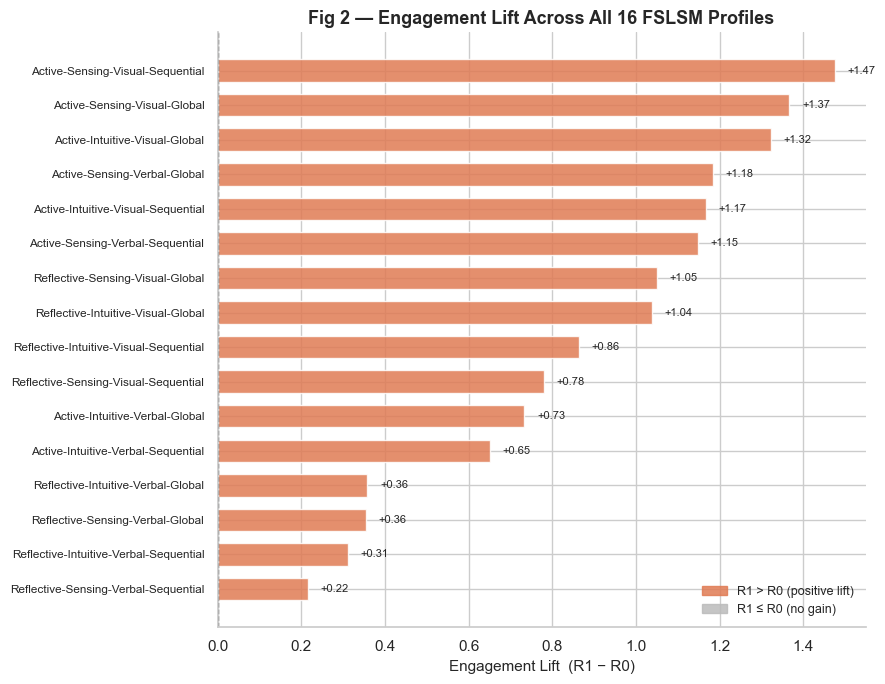

In [6]:
pivot = (df.groupby(['profile_label', 'mode'])['engagement']
           .mean()
           .unstack('mode'))
lift  = (pivot['R1'] - pivot['R0']).sort_values(ascending=True)

colors = [C_R1 if v >= 0 else C_NEG for v in lift.values]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(range(len(lift)), lift.values, color=colors, alpha=ALPHA, height=0.65)
ax.axvline(0, color='black', linewidth=0.9, linestyle='--')

ax.set_yticks(range(len(lift)))
ax.set_yticklabels(lift.index, fontsize=8.5)
ax.set_xlabel('Engagement Lift  (R1 − R0)', fontsize=11)
ax.set_title('Fig 2 — Engagement Lift Across All 16 FSLSM Profiles',
             fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

# Annotate lift values next to each bar
for i, v in enumerate(lift.values):
    offset = 0.03 if v >= 0 else -0.03
    ha = 'left' if v >= 0 else 'right'
    ax.text(v + offset, i, f'{v:+.2f}', va='center', ha=ha, fontsize=8)

# Legend
ax.legend(handles=[
    mpatches.Patch(color=C_R1, alpha=ALPHA, label='R1 > R0 (positive lift)'),
    mpatches.Patch(color=C_NEG, alpha=ALPHA, label='R1 ≤ R0 (no gain)'),
], loc='lower right', frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_lift_by_profile.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()


## Fig 3 — Score Distribution (R0 vs R1)
Shows the *shape* of the effect, not just the mean. Violin + strip to reveal full distribution.

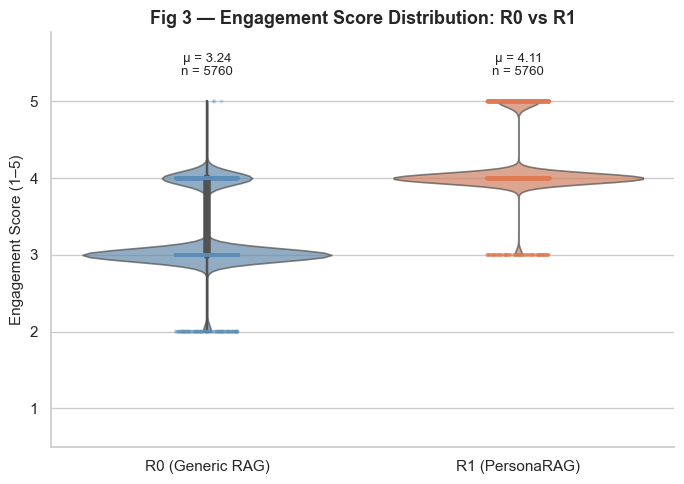

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

palette = {'R0': C_R0, 'R1': C_R1}
sns.violinplot(data=df, x='mode', y='engagement', palette=palette,
               inner='box', alpha=0.72, ax=ax, order=['R0', 'R1'],
               cut=0, linewidth=1.2)
sns.stripplot(data=df, x='mode', y='engagement', palette=palette,
              alpha=0.28, size=2.8, jitter=True, ax=ax, order=['R0', 'R1'])

# Annotate mean and count
for i, mode in enumerate(['R0', 'R1']):
    vals = df.loc[df['mode'] == mode, 'engagement']
    ax.text(i, 5.3, f'μ = {vals.mean():.2f}\nn = {len(vals)}',
            ha='center', va='bottom', fontsize=9.5)

ax.set_xticklabels(['R0 (Generic RAG)', 'R1 (PersonaRAG)'], fontsize=11)
ax.set_xlabel('')
ax.set_ylabel('Engagement Score (1–5)', fontsize=11)
ax.set_ylim(0.5, 5.9)
ax.set_title('Fig 3 — Engagement Score Distribution: R0 vs R1',
             fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_score_distribution.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()


## Fig 4 — SCS vs Engagement Scatter
Methodology validation chart. If SCS (style conformance) correlates with Engagement, the student agent is responding to real style differences.

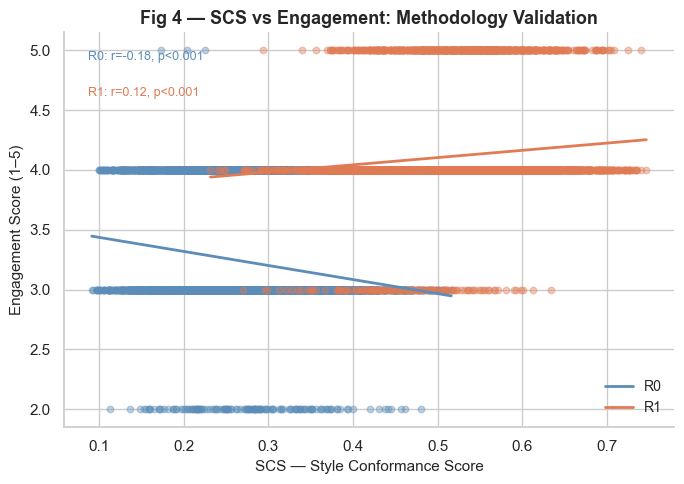

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

for mode, color in [('R0', C_R0), ('R1', C_R1)]:
    sub = df[df['mode'] == mode].dropna(subset=['scs', 'engagement'])
    x, y = sub['scs'].values, sub['engagement'].values
    ax.scatter(x, y, c=color, alpha=0.38, s=22, zorder=2)

    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 200)
    ax.plot(xline, m * xline + b, color=color, linewidth=2.0,
            label=f'{mode}', zorder=3)

    r, p = stats.pearsonr(x, y)
    p_str = 'p<0.001' if p < 0.001 else f'p={p:.3f}'
    y_pos = 0.93 if mode == 'R0' else 0.84
    ax.text(0.04, y_pos, f'{mode}: r={r:.2f}, {p_str}',
            transform=ax.transAxes, fontsize=9, color=color)

ax.set_xlabel('SCS — Style Conformance Score', fontsize=11)
ax.set_ylabel('Engagement Score (1–5)', fontsize=11)
ax.set_title('Fig 4 — SCS vs Engagement: Methodology Validation',
             fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_scs_vs_engagement.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()


## Fig 5 — Radar Chart (all 5 metrics normalised)
Thesis summary figure. One image shows the full result: R1 dominates on style metrics, RR shows a small deficit.

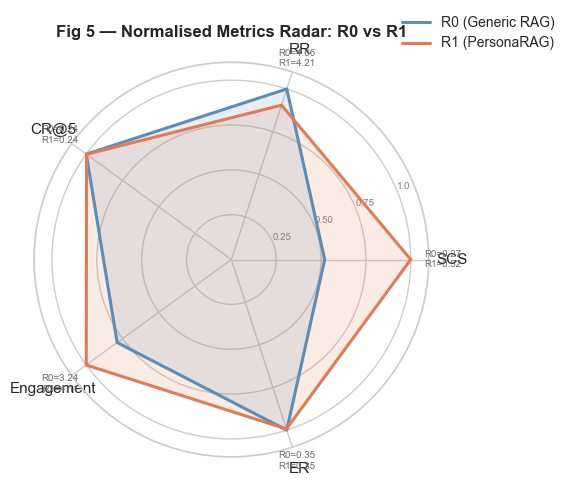

In [9]:
# Read metric means from summary JSON
r0_vals = [summary['metrics'][k]['R0']['mean'] for k in METRIC_JSON]
r1_vals = [summary['metrics'][k]['R1']['mean'] for k in METRIC_JSON]

# Normalise each metric to [0, 1] relative to its max across both conditions
norms   = [max(a, b) for a, b in zip(r0_vals, r1_vals)]
norm_r0 = [v / n if n > 0 else 0 for v, n in zip(r0_vals, norms)]
norm_r1 = [v / n if n > 0 else 0 for v, n in zip(r1_vals, norms)]

# Close the polygon
n_metrics = len(METRIC_LABELS)
angles    = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles   += angles[:1]
norm_r0  += norm_r0[:1]
norm_r1  += norm_r1[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})

ax.plot(angles, norm_r0, color=C_R0, linewidth=2.2, linestyle='solid', label='R0 (Generic RAG)')
ax.fill(angles, norm_r0, color=C_R0, alpha=0.15)
ax.plot(angles, norm_r1, color=C_R1, linewidth=2.2, linestyle='solid', label='R1 (PersonaRAG)')
ax.fill(angles, norm_r1, color=C_R1, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(METRIC_LABELS, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_yticks([0.25, 0.50, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.0'], fontsize=7, color='grey')
ax.set_title('Fig 5 — Normalised Metrics Radar: R0 vs R1',
             fontsize=12, fontweight='bold', pad=18)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), frameon=False, fontsize=10)

# Annotate raw means on each spoke
for angle, label, v0, v1, n_val in zip(
        angles[:-1], METRIC_LABELS, r0_vals, r1_vals, norms):
    ax.text(angle, 1.18,
            f'R0={v0:.2f}\nR1={v1:.2f}',
            ha='center', va='center', fontsize=7, color='dimgrey')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_radar.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()


## Fig 6 — Per-Profile Consistency (16 profiles, ±1 SD bands)
Methodological validation chart. Checks whether R1 consistently outperforms R0 across all 16 profiles.

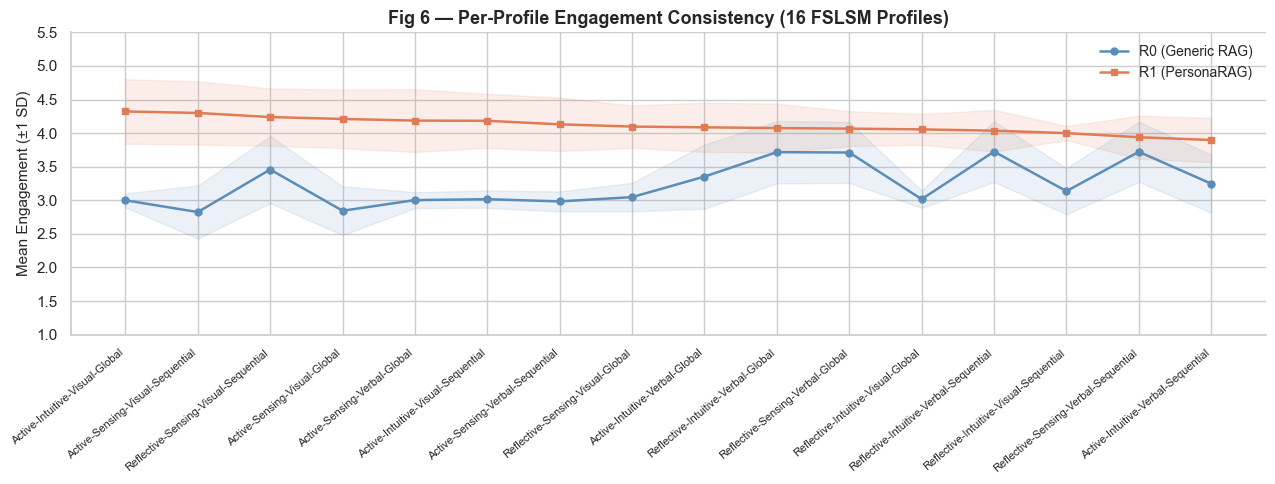

In [10]:
agg = (df.groupby(['profile_label', 'mode'])['engagement']
         .agg(['mean', 'std'])
         .reset_index())

agg_r0 = agg[agg['mode'] == 'R0'].set_index('profile_label')
agg_r1 = agg[agg['mode'] == 'R1'].set_index('profile_label')

# Sort by R1 mean descending
order  = agg_r1['mean'].sort_values(ascending=False).index.tolist()
agg_r0 = agg_r0.reindex(order)
agg_r1 = agg_r1.reindex(order)

x = np.arange(len(order))

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(x, agg_r0['mean'].values, 'o-', color=C_R0,
        linewidth=1.8, markersize=5, label='R0 (Generic RAG)')
ax.fill_between(x,
                agg_r0['mean'] - agg_r0['std'],
                agg_r0['mean'] + agg_r0['std'],
                color=C_R0, alpha=0.12)

ax.plot(x, agg_r1['mean'].values, 's-', color=C_R1,
        linewidth=1.8, markersize=5, label='R1 (PersonaRAG)')
ax.fill_between(x,
                agg_r1['mean'] - agg_r1['std'],
                agg_r1['mean'] + agg_r1['std'],
                color=C_R1, alpha=0.12)

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Mean Engagement (±1 SD)', fontsize=11)
ax.set_ylim(1.0, 5.5)
ax.set_title('Fig 6 — Per-Profile Engagement Consistency (16 FSLSM Profiles)',
             fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig6_profile_consistency.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()


## Fig 7 — Style–Accuracy Tradeoff Scatter
Most novel chart. Shows the relationship between engagement gain and RR delta across the 8 FSLSM poles (4 dimensions × 2 poles). A negative slope indicates that poles with the highest engagement gain show the largest RR deficit.

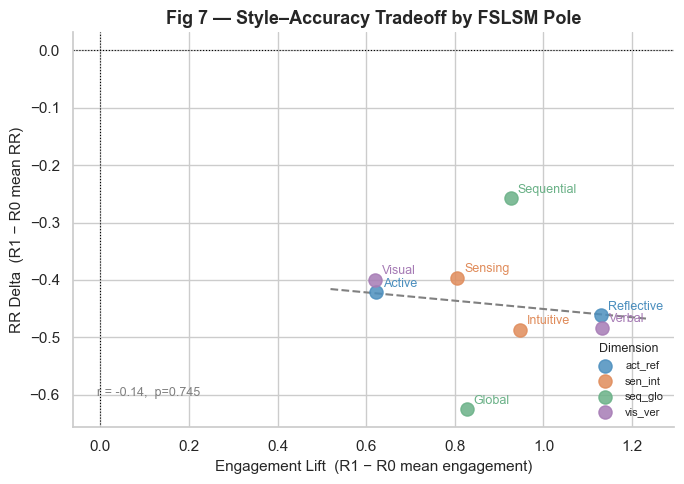


Tradeoff table:
     label  eng_lift  rr_delta
Reflective    +1.131    -0.462
    Active    +0.622    -0.422
 Intuitive    +0.947    -0.487
   Sensing    +0.806    -0.396
    Verbal    +1.133    -0.484
    Visual    +0.619    -0.400
    Global    +0.826    -0.625
Sequential    +0.926    -0.258


In [11]:
# Build 8-point dataset: one point per (dim, pole) combination
rows = []
for dim in DIM_NAMES:
    for pole in [-1, 1]:
        mask = df[dim] == pole
        v0   = df.loc[mask & (df['mode'] == 'R0')]
        v1   = df.loc[mask & (df['mode'] == 'R1')]
        rows.append({
            'label'    : DIM_LABELS[dim][pole],
            'dimension': dim,
            'eng_lift' : v1['engagement'].mean() - v0['engagement'].mean(),
            'rr_delta' : v1['rr'].mean()         - v0['rr'].mean(),
        })

pts = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 5))

# Colour points by dimension
dim_colors = ['#4C8FBE', '#E08C5B', '#6AB187', '#A67BB5']
for (dim, grp), col in zip(pts.groupby('dimension'), dim_colors):
    ax.scatter(grp['eng_lift'], grp['rr_delta'], color=col,
               s=90, zorder=3, alpha=ALPHA, label=dim)
    for _, row in grp.iterrows():
        ax.annotate(row['label'],
                    (row['eng_lift'], row['rr_delta']),
                    xytext=(5, 4), textcoords='offset points',
                    fontsize=9, color=col)

# Regression line over all 8 points
if len(pts) > 2:
    xv, yv = pts['eng_lift'].values, pts['rr_delta'].values
    m, b   = np.polyfit(xv, yv, 1)
    xline  = np.linspace(xv.min() - 0.1, xv.max() + 0.1, 200)
    ax.plot(xline, m * xline + b, color='grey',
            linewidth=1.5, linestyle='--', zorder=1)
    r, p   = stats.pearsonr(xv, yv)
    p_str  = 'p<0.001' if p < 0.001 else f'p={p:.3f}'
    ax.text(0.04, 0.08, f'r = {r:.2f},  {p_str}',
            transform=ax.transAxes, fontsize=9, color='grey')

ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.axvline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_xlabel('Engagement Lift  (R1 − R0 mean engagement)', fontsize=11)
ax.set_ylabel('RR Delta  (R1 − R0 mean RR)', fontsize=11)
ax.set_title('Fig 7 — Style–Accuracy Tradeoff by FSLSM Pole',
             fontsize=13, fontweight='bold')
ax.legend(title='Dimension', frameon=False, fontsize=8, title_fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig7_tradeoff_scatter.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

print('\nTradeoff table:')
print(pts[['label', 'eng_lift', 'rr_delta']].to_string(index=False, float_format='{:+.3f}'.format))


## Fig 8 — Per-Profile A/B Dumbbell: SCS, Engagement & RR
Direct R0 vs R1 comparison for all 16 FSLSM profiles across the three key metrics.
Each dot-pair shows where a profile starts (R0, blue) and ends (R1, orange); the connecting line is orange when R1 > R0 and grey otherwise.
Profiles are sorted by R1 Engagement descending.

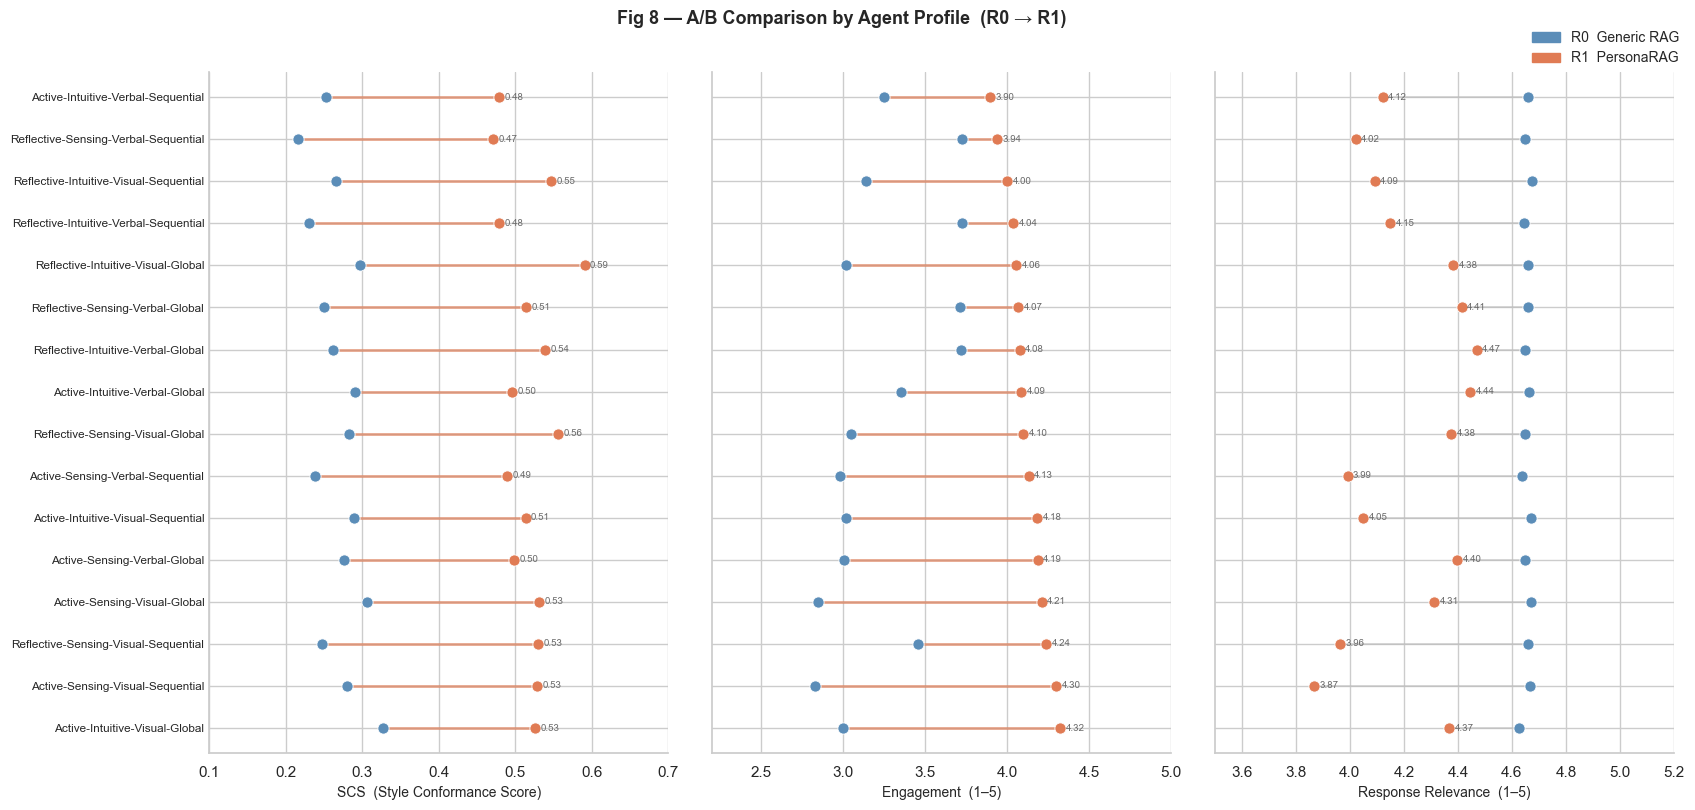

Profile,SCS R0,SCS R1,ΔSCS,Eng R0,Eng R1,ΔEng,RR R0,RR R1,ΔRR
Active-Intuitive-Visual-Global,0.327,0.525,0.198,3.000,4.322,1.322,4.625,4.367,-0.258
Active-Sensing-Visual-Sequential,0.279,0.528,0.249,2.825,4.300,1.475,4.667,3.867,-0.800
Reflective-Sensing-Visual-Sequential,0.248,0.529,0.281,3.458,4.239,0.781,4.658,3.964,-0.694
Active-Sensing-Visual-Global,0.307,0.531,0.224,2.844,4.211,1.367,4.672,4.311,-0.361
Active-Sensing-Verbal-Global,0.275,0.499,0.223,3.003,4.186,1.183,4.647,4.397,-0.250
Active-Intuitive-Visual-Sequential,0.289,0.513,0.224,3.017,4.183,1.167,4.672,4.050,-0.622
Active-Sensing-Verbal-Sequential,0.238,0.489,0.251,2.983,4.131,1.147,4.636,3.992,-0.644
Reflective-Sensing-Visual-Global,0.283,0.556,0.273,3.047,4.097,1.050,4.650,4.375,-0.275
Active-Intuitive-Verbal-Global,0.291,0.496,0.205,3.353,4.086,0.733,4.664,4.444,-0.219
Reflective-Intuitive-Verbal-Global,0.262,0.539,0.277,3.717,4.075,0.358,4.647,4.469,-0.178


In [12]:
# ── Fig 8 — Per-Profile A/B Dumbbell: SCS, Engagement & RR ───────────
agg = (df.groupby(['profile_label', 'mode'])[['scs', 'engagement', 'rr']]
         .mean()
         .reset_index())

agg_r0 = agg[agg['mode'] == 'R0'].set_index('profile_label')
agg_r1 = agg[agg['mode'] == 'R1'].set_index('profile_label')

# Sort profiles by R1 Engagement descending
order  = agg_r1['engagement'].sort_values(ascending=False).index.tolist()
agg_r0 = agg_r0.reindex(order)
agg_r1 = agg_r1.reindex(order)
y = np.arange(len(order))

metrics = [
    ('scs',        'SCS  (Style Conformance Score)', (0.10, 0.70)),
    ('engagement', 'Engagement  (1–5)',               (2.20, 5.00)),
    ('rr',         'Response Relevance  (1–5)',        (3.50, 5.20)),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 8), sharey=True)
fig.suptitle('Fig 8 — A/B Comparison by Agent Profile  (R0 → R1)',
             fontsize=13, fontweight='bold', y=1.01)

patch_r0 = mpatches.Patch(color=C_R0, label='R0  Generic RAG')
patch_r1 = mpatches.Patch(color=C_R1, label='R1  PersonaRAG')

for ax, (col, xlabel, xlim) in zip(axes, metrics):
    v0 = agg_r0[col].values
    v1 = agg_r1[col].values

    # Connecting lines: orange = improvement, grey = regression
    for i, (a, b) in enumerate(zip(v0, v1)):
        color  = C_R1 if b >= a else C_NEG
        lw     = 2.0  if b >= a else 1.2
        ax.plot([a, b], [y[i], y[i]], color=color, linewidth=lw,
                alpha=0.65, zorder=1)

    # R0 dots (blue, hollow centre)
    ax.scatter(v0, y, color=C_R0, s=65, zorder=3,
               edgecolors='white', linewidths=0.6, label='R0')
    # R1 dots (orange, hollow centre)
    ax.scatter(v1, y, color=C_R1, s=65, zorder=3,
               edgecolors='white', linewidths=0.6, label='R1')

    # Annotate R1 value
    for i, b in enumerate(v1):
        ax.text(b + (xlim[1] - xlim[0]) * 0.012, y[i], f'{b:.2f}',
                va='center', fontsize=7.0, color='dimgrey')

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_xlim(xlim)
    ax.set_ylim(-0.6, len(order) - 0.4)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', length=0)

    if ax is axes[0]:
        ax.set_yticks(y)
        ax.set_yticklabels(order, fontsize=8.5)

fig.legend(handles=[patch_r0, patch_r1], loc='upper right',
           bbox_to_anchor=(1.0, 1.0), frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig8_profile_ab_dumbbell.png',
            dpi=FIG_DPI, bbox_inches='tight')
plt.show()

# ── Summary table ──────────────────────────────────────────────────────
summary_rows = []
for p in order:
    summary_rows.append({
        'Profile'   : p,
        'SCS R0'    : agg_r0.loc[p, 'scs'],
        'SCS R1'    : agg_r1.loc[p, 'scs'],
        'ΔSCS'      : agg_r1.loc[p, 'scs']        - agg_r0.loc[p, 'scs'],
        'Eng R0'    : agg_r0.loc[p, 'engagement'],
        'Eng R1'    : agg_r1.loc[p, 'engagement'],
        'ΔEng'      : agg_r1.loc[p, 'engagement']  - agg_r0.loc[p, 'engagement'],
        'RR R0'     : agg_r0.loc[p, 'rr'],
        'RR R1'     : agg_r1.loc[p, 'rr'],
        'ΔRR'       : agg_r1.loc[p, 'rr']          - agg_r0.loc[p, 'rr'],
    })

df_sum = pd.DataFrame(summary_rows)

def color_delta(val):
    if val > 0.05:  return 'color: #2e7d32'
    if val < -0.05: return 'color: #c62828'
    return 'color: #555555'

display(
    df_sum.style
    .format({c: '{:.3f}' for c in df_sum.columns if c != 'Profile'})
    .map(color_delta, subset=['ΔSCS', 'ΔEng', 'ΔRR'])
    .set_caption('Per-Profile A/B Summary  (n = 360 sessions per profile per condition)')
    .hide(axis='index')
)

## Fig 9 — R0 vs R1 by Question Type & Retrieval Strategy
Does the benefit of FSLSM personalization depend on *what kind of question* is being asked?
Panel A groups by question type (4 categories); Panel B groups by retrieval strategy (3 categories).
Bars show mean ± SE; Δ is the R1−R0 lift annotated above each R1 bar.

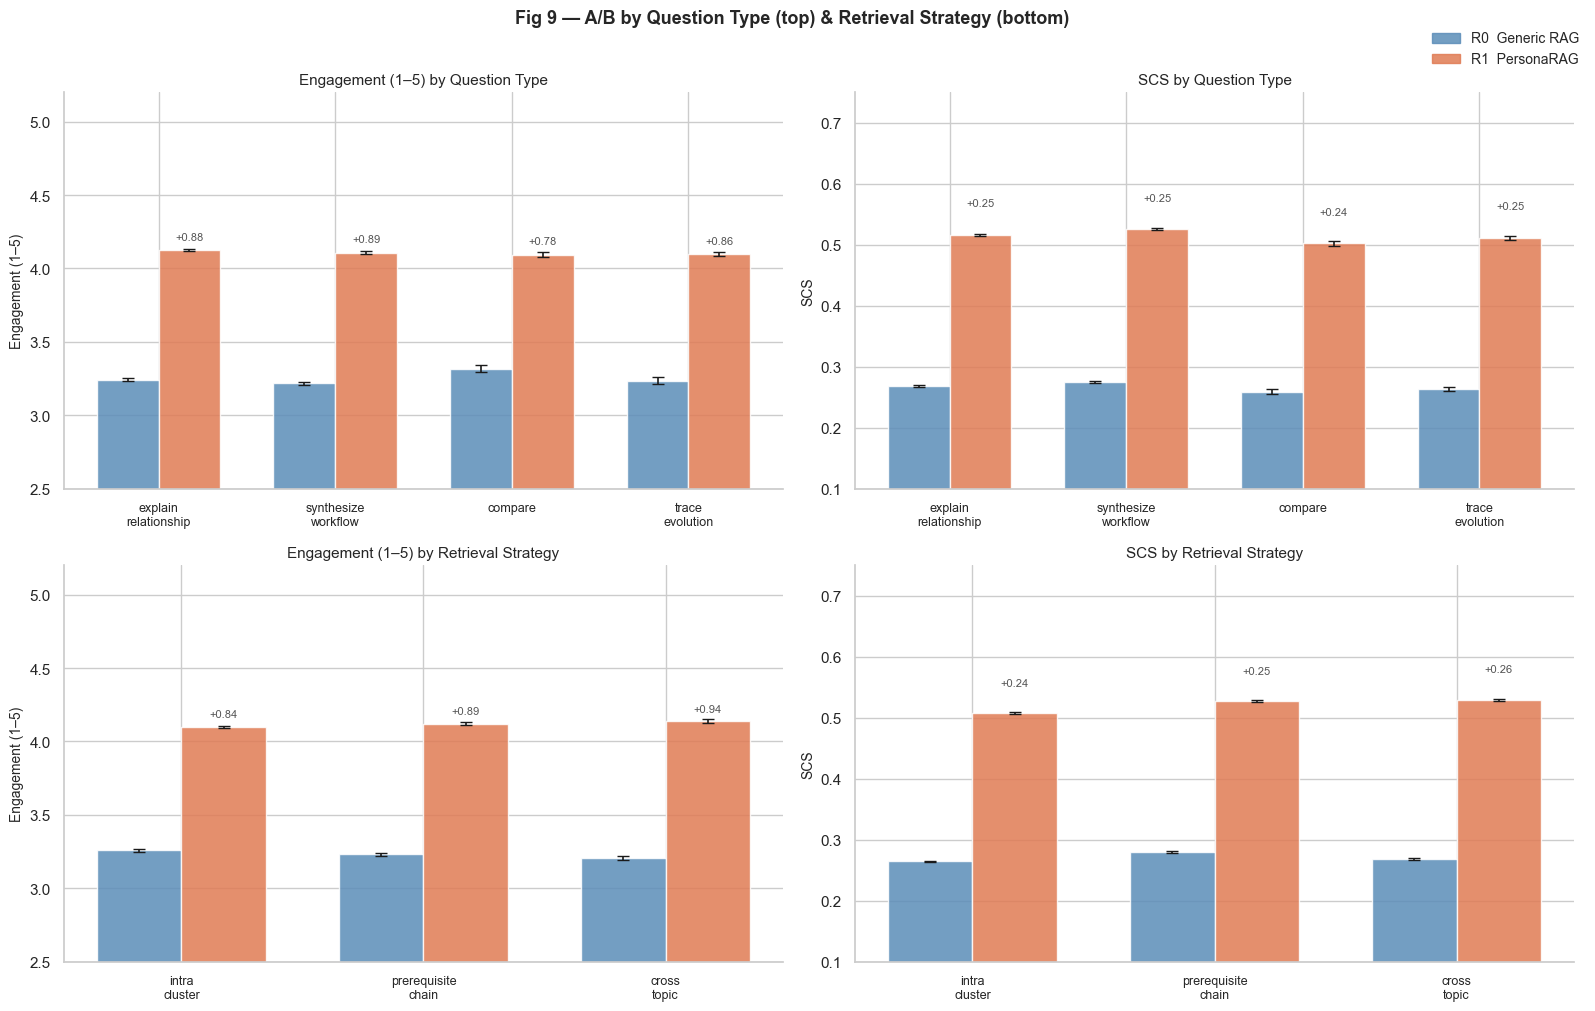

question_type,n (R0),Eng R0,Eng R1,ΔEng,SCS R0,SCS R1,ΔSCS,RR R0,RR R1,ΔRR
explain_relationship,2720,3.241,4.126,0.885,0.269,0.516,0.247,4.710,4.282,-0.428
synthesize_workflow,2080,3.216,4.107,0.891,0.274,0.525,0.251,4.596,4.142,-0.453
compare,480,3.317,4.094,0.777,0.259,0.502,0.244,4.485,4.037,-0.448
trace_evolution,480,3.233,4.098,0.865,0.263,0.511,0.248,4.775,4.312,-0.463


strategy,n (R0),Eng R0,Eng R1,ΔEng,SCS R0,SCS R1,ΔSCS,RR R0,RR R1,ΔRR
intra_cluster,2880,3.258,4.099,0.841,0.264,0.507,0.243,4.693,4.242,-0.451
prerequisite_chain,1520,3.230,4.120,0.890,0.280,0.527,0.247,4.678,4.203,-0.475
cross_topic,1360,3.204,4.139,0.935,0.268,0.529,0.261,4.551,4.167,-0.385


In [13]:
# ── Fig 9 — R0 vs R1 by Question Type & Strategy ─────────────────────
QTYPE_ORDER    = ['explain_relationship', 'synthesize_workflow', 'compare', 'trace_evolution']
STRATEGY_ORDER = ['intra_cluster', 'prerequisite_chain', 'cross_topic']
METRICS        = [('engagement', 'Engagement (1–5)'), ('scs', 'SCS')]

fig, big_axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Fig 9 — A/B by Question Type (top) & Retrieval Strategy (bottom)',
             fontsize=13, fontweight='bold', y=1.01)

bar_w = 0.35

def draw_group_bars(ax, groups, groupby_col, metric, ylabel):
    x = np.arange(len(groups))
    r0_m, r0_se, r1_m, r1_se = [], [], [], []
    for g in groups:
        sub = df[df[groupby_col] == g]
        v0 = sub[sub['mode'] == 'R0'][metric]
        v1 = sub[sub['mode'] == 'R1'][metric]
        r0_m.append(v0.mean()); r0_se.append(v0.sem())
        r1_m.append(v1.mean()); r1_se.append(v1.sem())

    b0 = ax.bar(x - bar_w/2, r0_m, bar_w, yerr=r0_se,
                color=C_R0, alpha=ALPHA, capsize=4, error_kw={'linewidth': 1.2},
                label='R0 Generic RAG')
    b1 = ax.bar(x + bar_w/2, r1_m, bar_w, yerr=r1_se,
                color=C_R1, alpha=ALPHA, capsize=4, error_kw={'linewidth': 1.2},
                label='R1 PersonaRAG')

    # Annotate Δ above each R1 bar
    for xi, (m0, m1) in enumerate(zip(r0_m, r1_m)):
        delta = m1 - m0
        sign  = '+' if delta >= 0 else ''
        ax.text(xi + bar_w/2, m1 + max(r1_se) + 0.04,
                f'{sign}{delta:.2f}', ha='center', va='bottom',
                fontsize=8, color='#555555')

    ax.set_xticks(x)
    labels = [g.replace('_', '\n') for g in groups]
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    return b0, b1

# Row 0 — by question type
for col, (metric, ylabel) in enumerate(METRICS):
    ax = big_axes[0][col]
    b0, b1 = draw_group_bars(ax, QTYPE_ORDER, 'question_type', metric, ylabel)
    ax.set_title(f'{ylabel} by Question Type', fontsize=11)
    if metric == 'engagement':
        ax.set_ylim(2.5, 5.2)
    else:
        ax.set_ylim(0.1, 0.75)

# Row 1 — by strategy
for col, (metric, ylabel) in enumerate(METRICS):
    ax = big_axes[1][col]
    b0, b1 = draw_group_bars(ax, STRATEGY_ORDER, 'strategy', metric, ylabel)
    ax.set_title(f'{ylabel} by Retrieval Strategy', fontsize=11)
    if metric == 'engagement':
        ax.set_ylim(2.5, 5.2)
    else:
        ax.set_ylim(0.1, 0.75)

fig.legend(handles=[
    mpatches.Patch(color=C_R0, alpha=ALPHA, label='R0  Generic RAG'),
    mpatches.Patch(color=C_R1, alpha=ALPHA, label='R1  PersonaRAG'),
], loc='upper right', bbox_to_anchor=(1.0, 1.0), frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig9_by_question_type.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

# ── Summary table ──────────────────────────────────────────────────────
for groupby_col, groups in [('question_type', QTYPE_ORDER), ('strategy', STRATEGY_ORDER)]:
    rows = []
    for g in groups:
        sub = df[df[groupby_col] == g]
        v0e = sub[sub['mode']=='R0']['engagement']
        v1e = sub[sub['mode']=='R1']['engagement']
        v0s = sub[sub['mode']=='R0']['scs']
        v1s = sub[sub['mode']=='R1']['scs']
        v0r = sub[sub['mode']=='R0']['rr']
        v1r = sub[sub['mode']=='R1']['rr']
        rows.append({
            groupby_col  : g,
            'n (R0)'     : len(v0e),
            'Eng R0'     : v0e.mean(), 'Eng R1': v1e.mean(), 'ΔEng': v1e.mean()-v0e.mean(),
            'SCS R0'     : v0s.mean(), 'SCS R1': v1s.mean(), 'ΔSCS': v1s.mean()-v0s.mean(),
            'RR R0'      : v0r.mean(), 'RR R1' : v1r.mean(), 'ΔRR' : v1r.mean()-v0r.mean(),
        })
    df_t = pd.DataFrame(rows)
    num_cols = [c for c in df_t.columns if c not in [groupby_col, 'n (R0)']]

    def color_delta(val):
        if val > 0.05:  return 'color: #2e7d32'
        if val < -0.05: return 'color: #c62828'
        return 'color: #555555'

    display(df_t.style
        .format({'n (R0)': '{:.0f}', **{c: '{:.3f}' for c in num_cols}})
        .map(color_delta, subset=['ΔEng', 'ΔSCS', 'ΔRR'])
        .set_caption(f'A/B Summary by {groupby_col}')
        .hide(axis='index'))

## Fig 10 — Interaction Heatmap: Engagement Lift by Question Type × FSLSM Dimension
Each cell shows mean ΔEngagement (R1 − R0) for a combination of question type and FSLSM dimension pole.
Darker orange = larger gain from personalization; white/grey = no gain.
This reveals whether certain learning-style dimensions are more effective for specific question types.

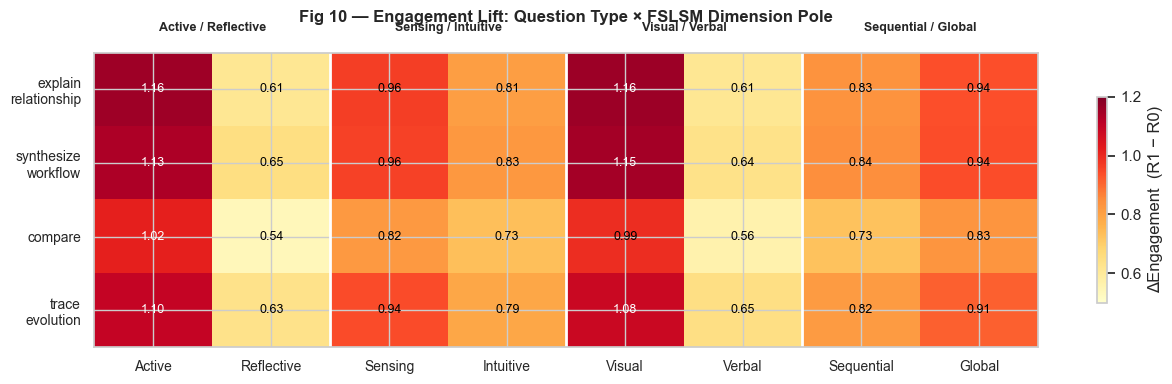

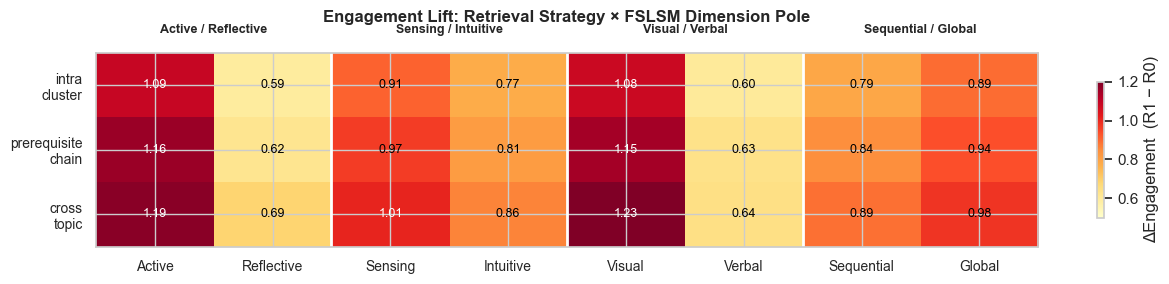

In [14]:
# ── Fig 10 — Engagement Lift Heatmap: Question Type × FSLSM Dimension ─
POLE_LABELS = {
    'act_ref': ['Active', 'Reflective'],
    'sen_int': ['Sensing', 'Intuitive'],
    'vis_ver': ['Visual', 'Verbal'],
    'seq_glo': ['Sequential', 'Global'],
}
# Build columns: one per (dim, pole) → 8 columns
col_defs = []
for dim in DIM_NAMES:
    for pole_val, pole_name in zip([-1, 1], POLE_LABELS[dim]):
        col_defs.append((dim, pole_val, pole_name))

rows_heat = []
for qtype in QTYPE_ORDER:
    row = {'Question Type': qtype}
    for dim, pole_val, pole_name in col_defs:
        mask = (df['question_type'] == qtype) & (df[dim] == pole_val)
        v0 = df.loc[mask & (df['mode'] == 'R0'), 'engagement']
        v1 = df.loc[mask & (df['mode'] == 'R1'), 'engagement']
        row[pole_name] = v1.mean() - v0.mean() if len(v0) > 0 else np.nan
    rows_heat.append(row)

df_heat = pd.DataFrame(rows_heat).set_index('Question Type')
col_order = [pole_name for _, _, pole_name in col_defs]
df_heat = df_heat[col_order]

# ── Plot: main heatmap ──
fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(df_heat.values, cmap='YlOrRd', aspect='auto', vmin=0.5, vmax=1.2)

ax.set_xticks(range(len(col_order)))
ax.set_xticklabels(col_order, fontsize=10)
ax.set_yticks(range(len(QTYPE_ORDER)))
ax.set_yticklabels([q.replace('_', '\n') for q in QTYPE_ORDER], fontsize=10)

# Vertical dividers between dimensions
for i in [2, 4, 6]:
    ax.axvline(i - 0.5, color='white', linewidth=2)

# Dimension labels above columns
dim_centres = [0.5, 2.5, 4.5, 6.5]
for cx, dim in zip(dim_centres, DIM_TITLES):
    ax.text(cx, -0.75, dim, ha='center', va='bottom', fontsize=9,
            fontweight='bold', transform=ax.transData)

# Annotate cell values
for i in range(len(QTYPE_ORDER)):
    for j in range(len(col_order)):
        val = df_heat.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color='black' if val < 1.0 else 'white')

fig.colorbar(im, ax=ax, shrink=0.7, label='ΔEngagement  (R1 − R0)')
ax.set_title('Fig 10 — Engagement Lift: Question Type × FSLSM Dimension Pole',
             fontsize=12, fontweight='bold', pad=22)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10_qtype_dim_heatmap.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

# ── Strategy × Dimension heatmap ──────────────────────────────────────
rows_s = []
for strat in STRATEGY_ORDER:
    row = {'Strategy': strat}
    for dim, pole_val, pole_name in col_defs:
        mask = (df['strategy'] == strat) & (df[dim] == pole_val)
        v0 = df.loc[mask & (df['mode'] == 'R0'), 'engagement']
        v1 = df.loc[mask & (df['mode'] == 'R1'), 'engagement']
        row[pole_name] = v1.mean() - v0.mean() if len(v0) > 0 else np.nan
    rows_s.append(row)

df_s = pd.DataFrame(rows_s).set_index('Strategy')[col_order]

fig2, ax2 = plt.subplots(figsize=(13, 3))
im2 = ax2.imshow(df_s.values, cmap='YlOrRd', aspect='auto', vmin=0.5, vmax=1.2)

ax2.set_xticks(range(len(col_order)))
ax2.set_xticklabels(col_order, fontsize=10)
ax2.set_yticks(range(len(STRATEGY_ORDER)))
ax2.set_yticklabels([s.replace('_', '\n') for s in STRATEGY_ORDER], fontsize=10)

for i in [2, 4, 6]:
    ax2.axvline(i - 0.5, color='white', linewidth=2)
for cx, dim in zip(dim_centres, DIM_TITLES):
    ax2.text(cx, -0.75, dim, ha='center', va='bottom', fontsize=9,
             fontweight='bold', transform=ax2.transData)
for i in range(len(STRATEGY_ORDER)):
    for j in range(len(col_order)):
        val = df_s.values[i, j]
        ax2.text(j, i, f'{val:.2f}', ha='center', va='center',
                 fontsize=9, color='black' if val < 1.0 else 'white')

fig2.colorbar(im2, ax=ax2, shrink=0.7, label='ΔEngagement  (R1 − R0)')
ax2.set_title('Engagement Lift: Retrieval Strategy × FSLSM Dimension Pole',
              fontsize=12, fontweight='bold', pad=22)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10b_strategy_dim_heatmap.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()